In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [15]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["species"] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


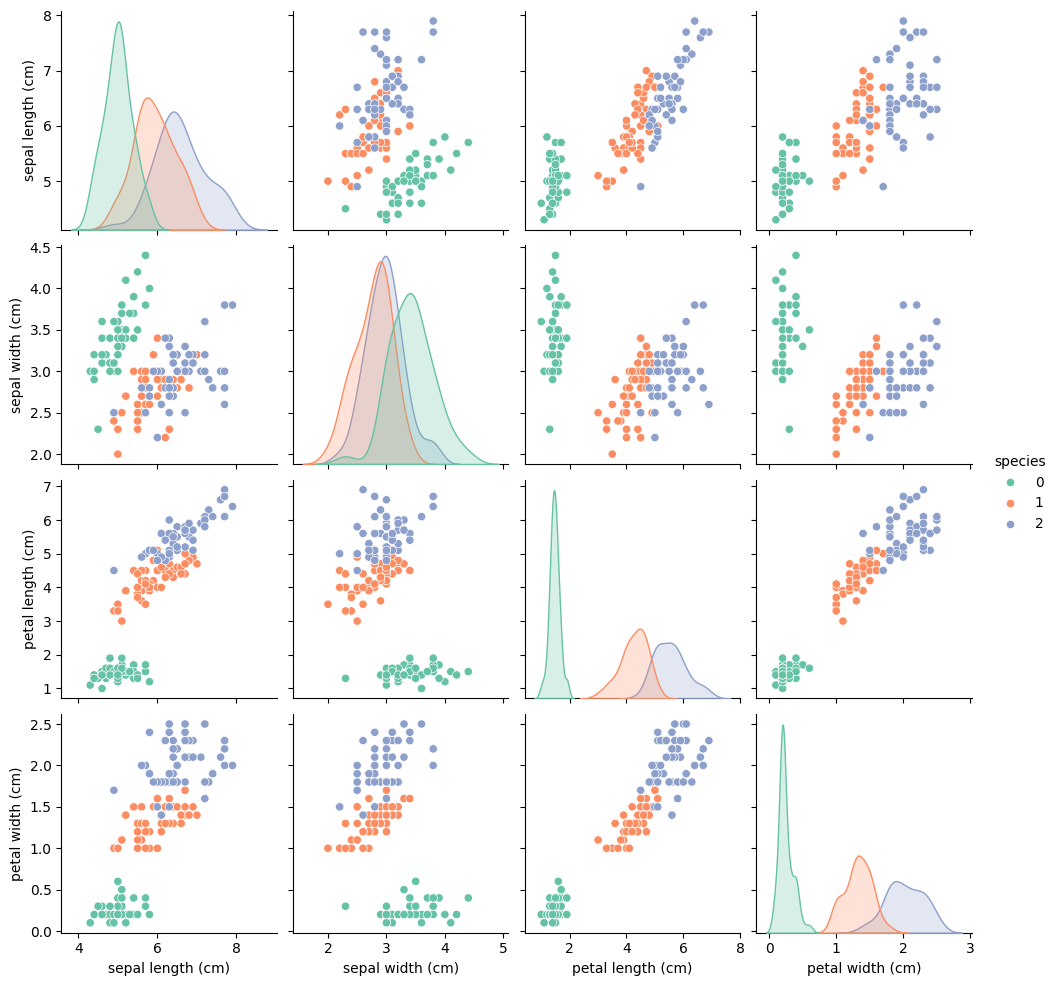

In [16]:
sns.pairplot(df, hue="species", palette="Set2")
plt.show()

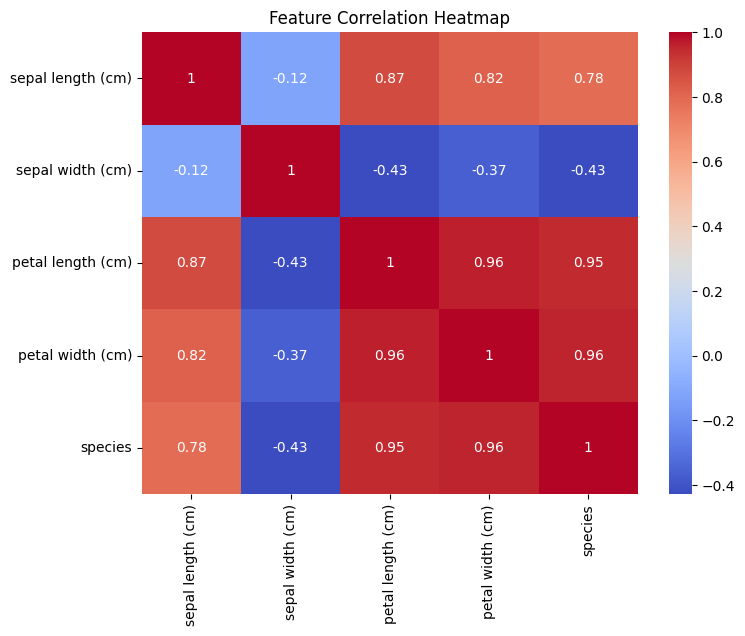

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

In [21]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

In [22]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

In [23]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "KNN", "SVM"],
    "Accuracy": [dt_acc, knn_acc, svm_acc]
})

print(results)

           Model  Accuracy
0  Decision Tree  1.000000
1            KNN  1.000000
2            SVM  0.966667


C:\Users\sushank varshith\AppData\Local\Temp\ipykernel_8336\3453367940.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=results, palette="viridis")


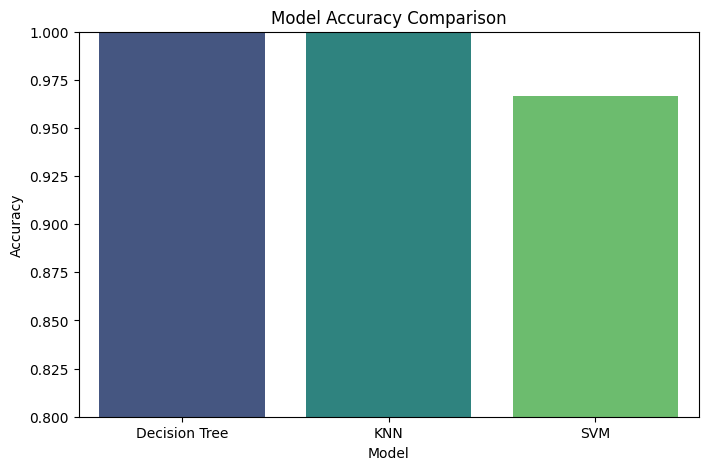

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="Accuracy", data=results, palette="viridis")

plt.title("Model Accuracy Comparison")
plt.ylim(0.8,1.0)
plt.show()

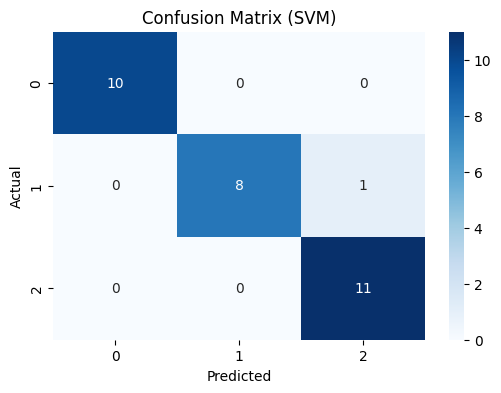

In [25]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, svm_pred),
            annot=True,
            cmap="Blues",
            fmt="d")

plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



In [27]:
sepal_length = float(input("Enter Sepal Length: "))
sepal_width = float(input("Enter Sepal Width: "))
petal_length = float(input("Enter Petal Length: "))
petal_width = float(input("Enter Petal Width: "))

sample = [[sepal_length, sepal_width, petal_length, petal_width]]

sample = scaler.transform(sample)

prediction = svm.predict(sample)

print("Predicted Flower Species:", target_names[prediction[0]])

Predicted Flower Species: virginica
